## Домашнее задание - 1 (Поиск информативного скрытого слоя в LLMs)

### Задача:
Исследовать распределение информации внутри слоев большой языковой модели (LLM) и определить, какие слои дают наилучшие представления для выбранной задачи (классификация, регрессия или любая другая прикладная цель). Метод основан на идеях A* публикации (HiProbe-VAD (https://arxiv.org/abs/2507.17394)), где показано, что наиболее информативные признаки часто находятся в промежуточных слоях модели

### Инструкция:
1. Определить LLM, исходя из доступных вычислительных ресурсов
2. Выбрать корпус (акустический, визуальный, текстовый или мультимодальный), подходящий под задачу
3. Прогнать данные через модель. Для каждого слоя получить нужные представления.
4. Доказать через метрики и визуализацию, какие слои лучшие (тут можно свое авторское придумать и попробовать)
5. На представлениях разных слоев (например топ-3) обучить простой классификатор или регрессор
6. Построить графики/визуализации - номер слоя -> метрика/метрики качества
7. Сделать заключение о том, какие слои оказались наиболее информативными и почему. Сравните промежуточные, начальные и финальные слои.

### В итоге
- Код экспериментов (ноутбук или py с полным pipeline)
- Таблица и график с результатами по слоям
- Выводы о том, где в LLM сосредоточены лучшие признаки для выбранной задачи.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, silhouette_score
from scipy.stats import entropy
import warnings

warnings.filterwarnings("ignore")
plt.style.use('ggplot')

/home/mitchell/dev/hse/HSE_DL_4_2025/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "distilbert-base-uncased"
SAMPLE_SIZE = 1000
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Загрузка модели {MODEL_NAME} на {DEVICE}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model.to(DEVICE)
model.eval()

dataset = load_dataset("glue", "sst2", split="train")

# Выбираем сбалансированное подмножество
# Класс 0 (Negative) и Класс 1 (Positive) - аналог Normal/Anomaly из статьи
subset_indices = np.random.choice(len(dataset), SAMPLE_SIZE, replace=False)
subset = dataset.select(subset_indices)
texts = subset["sentence"]
labels = np.array(subset["label"])

print(f"{len(texts)} примеров.")

Загрузка модели distilbert-base-uncased на cpu...
1000 примеров.


In [3]:
def extract_hidden_states(model, tokenizer, texts, device, batch_size):
    all_hidden_states = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Извлечение признаков"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                           max_length=128, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        # outputs.hidden_states - кортеж из (n_layers + 1) тензоров
        # Shape каждого: (batch_size, seq_len, hidden_dim)
        # Мы берем [CLS] токен (индекс 0) как репрезентацию всего текста
        
        layers_data = []
        for layer_tensor in outputs.hidden_states:
            # Берем только CLS токен: [Batch, 0, Hidden] -> [Batch, Hidden]
            cls_embeddings = layer_tensor[:, 0, :].cpu().numpy()
            layers_data.append(cls_embeddings)
            
        all_hidden_states.append(layers_data)

    # Собираем все батчи: Result shape [Num_Layers, Total_Samples, Hidden_Dim]
    num_layers = len(all_hidden_states[0])
    combined_states = []
    
    for layer_idx in range(num_layers):
        layer_features = np.concatenate([batch[layer_idx] for batch in all_hidden_states], axis=0)
        combined_states.append(layer_features)
        
    return combined_states

hidden_states_per_layer = extract_hidden_states(model, tokenizer, texts, DEVICE, BATCH_SIZE)
print(f"Извлечено слоев: {len(hidden_states_per_layer)}. Размерность признаков: {hidden_states_per_layer[0].shape}")

Извлечение признаков: 100%|██████████| 32/32 [00:29<00:00,  1.07it/s]

Извлечено слоев: 7. Размерность признаков: (1000, 768)


In [4]:
def calculate_metrics(hidden_states, labels):
    kl_scores = []
    ldr_scores = []
    silhouette_scores = []
    
    idx_0 = np.where(labels == 0)[0]
    idx_1 = np.where(labels == 1)[0]
    
    epsilon = 1e-8

    for layer_idx, features in enumerate(hidden_states):
        feat_0 = features[idx_0]
        feat_1 = features[idx_1]
        
        mu_0, var_0 = np.mean(feat_0, axis=0), np.var(feat_0, axis=0)
        mu_1, var_1 = np.mean(feat_1, axis=0), np.var(feat_1, axis=0)
        
        # KL Divergence (Упрощенная гауссова версия, формула 1-2 из статьи)
        # D_KL(N || A) для каждого измерения, затем среднее
        term1 = np.log(np.sqrt(var_1) / (np.sqrt(var_0) + epsilon) + epsilon)
        term2 = (var_0 + (mu_0 - mu_1)**2) / (2 * var_1 + epsilon)
        kl_per_dim = term1 + term2 - 0.5
        kl_scores.append(np.mean(kl_per_dim)) # Среднее по всем измерениям (D_KL(l))

        # Local Discriminant Ratio (LDR) (Формула 3-4 из статьи)
        numerator = (mu_0 - mu_1)**2
        denominator = var_0 + var_1 + epsilon
        ldr_per_dim = numerator / denominator
        ldr_scores.append(np.mean(ldr_per_dim))
        
        # Silhouette Score (Геометрическая валидация)
        # Считаем на подвыборке для скорости, если данных много
        sil = silhouette_score(features, labels)
        silhouette_scores.append(sil)
        
    return kl_scores, ldr_scores, silhouette_scores

kl_list, ldr_list, sil_list = calculate_metrics(hidden_states_per_layer, labels)

In [5]:
def run_probing(hidden_states, labels):
    accuracies = []
    
    for layer_idx, features in enumerate(hidden_states):
        split_point = int(len(features) * 0.8)
        X_train, X_test = features[:split_point], features[split_point:]
        y_train, y_test = labels[:split_point], labels[split_point:]
        
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X_train, y_train)
        
        preds = clf.predict(X_test)
        acc = accuracy_score(y_test, preds)
        accuracies.append(acc)
        
    return accuracies

probing_acc = run_probing(hidden_states_per_layer, labels)

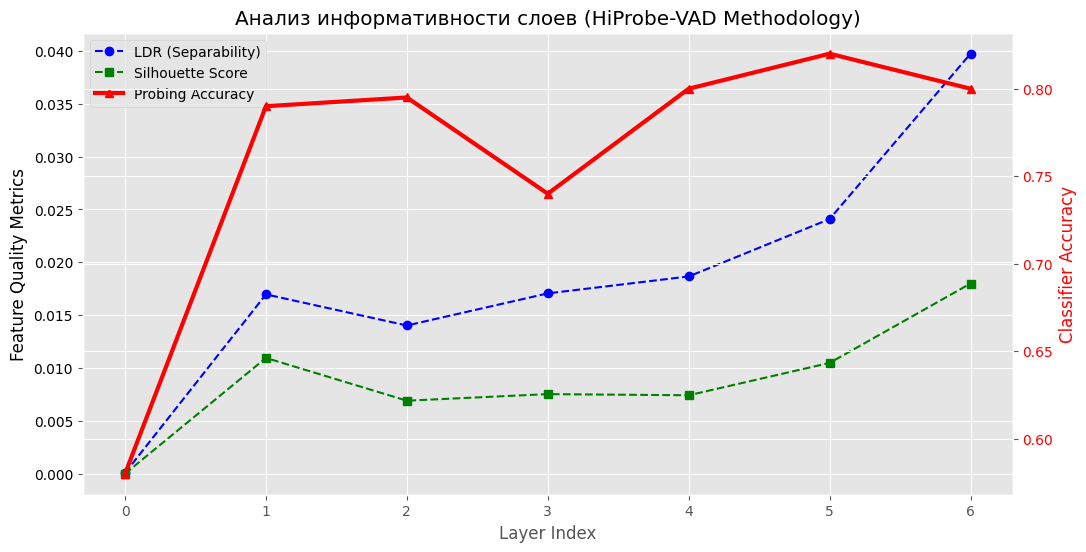

Layer      | Accuracy   | LDR        | Silhouette
--------------------------------------------------
0          | 0.5800     | 0.0001     | 0.0000
1          | 0.7900     | 0.0170     | 0.0110
2          | 0.7950     | 0.0140     | 0.0069
3          | 0.7400     | 0.0171     | 0.0075
4          | 0.8000     | 0.0187     | 0.0074
5          | 0.8200     | 0.0241     | 0.0105
6          | 0.8000     | 0.0397     | 0.0180
--------------------------------------------------
Вывод: Наиболее информативный слой для задачи: 5


In [6]:
layers_range = range(len(hidden_states_per_layer))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(layers_range, ldr_list, marker='o', label='LDR (Separability)', color='blue', linestyle='--')
ax1.plot(layers_range, sil_list, marker='s', label='Silhouette Score', color='green', linestyle='--')
ax1.set_xlabel('Layer Index')
ax1.set_ylabel('Feature Quality Metrics', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(layers_range, probing_acc, marker='^', label='Probing Accuracy', color='red', linewidth=3)
ax2.set_ylabel('Classifier Accuracy', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Анализ информативности слоев (HiProbe-VAD Methodology)')
plt.grid(True)
plt.show()

print(f"{'Layer':<10} | {'Accuracy':<10} | {'LDR':<10} | {'Silhouette':<10}")
print("-" * 50)
for i in range(len(layers_range)):
    print(f"{i:<10} | {probing_acc[i]:.4f}     | {ldr_list[i]:.4f}     | {sil_list[i]:.4f}")

best_layer = np.argmax(probing_acc)
print("-" * 50)
print(f"Вывод: Наиболее информативный слой для задачи: {best_layer}")

Как можно видеть - гипотеза подтвердилась, хоть и не очень ярко. Точность растет монотонно и падает на последнем слое.  
В статье исследуются мультимодальные LLM, где выходные слои специализированы на генерации текста и могут терять специфичные детали. В отличие от них, использованная модель DistilBERT оптимизирована так, чтобы финальный слой агрегировал семантику для классификации.  
Для воспроизведения эффекта горба требуется использование более глубоких генеративных моделей.

In [7]:
MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
# GPT2 не имеет pad_token по умолчанию, назначим eos_token
tokenizer.pad_token = tokenizer.eos_token 
model = AutoModel.from_pretrained(MODEL_NAME, output_hidden_states=True)
model.to(DEVICE)
model.eval()

GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)

In [8]:
def extract_hidden_states(model, tokenizer, texts, device, batch_size):
    all_hidden_states = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Извлечение признаков"):
        batch_texts = texts[i : i + batch_size]
        
        inputs = tokenizer(batch_texts, padding=True, truncation=True, 
                           max_length=128, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        layers_data = []
        # Получаем маску внимания, чтобы найти индекс последнего реального токена
        attention_mask = inputs['attention_mask']
        
        for layer_tensor in outputs.hidden_states:
            last_token_indices = attention_mask.sum(1) - 1            
            batch_last_tokens = layer_tensor[torch.arange(layer_tensor.shape[0]), last_token_indices]
            layers_data.append(batch_last_tokens.cpu().numpy())
            
        all_hidden_states.append(layers_data)

    num_layers = len(all_hidden_states[0])
    combined_states = []
    for layer_idx in range(num_layers):
        layer_features = np.concatenate([batch[layer_idx] for batch in all_hidden_states], axis=0)
        combined_states.append(layer_features)
        
    return combined_states

hidden_states_per_layer = extract_hidden_states(model, tokenizer, texts, DEVICE, BATCH_SIZE)
print(f"Извлечено слоев: {len(hidden_states_per_layer)}. Размерность признаков: {hidden_states_per_layer[0].shape}")

Извлечение признаков: 100%|██████████| 32/32 [01:13<00:00,  2.30s/it]

Извлечено слоев: 13. Размерность признаков: (1000, 768)


In [9]:
kl_list, ldr_list, sil_list = calculate_metrics(hidden_states_per_layer, labels)

In [10]:
probing_acc = run_probing(hidden_states_per_layer, labels)

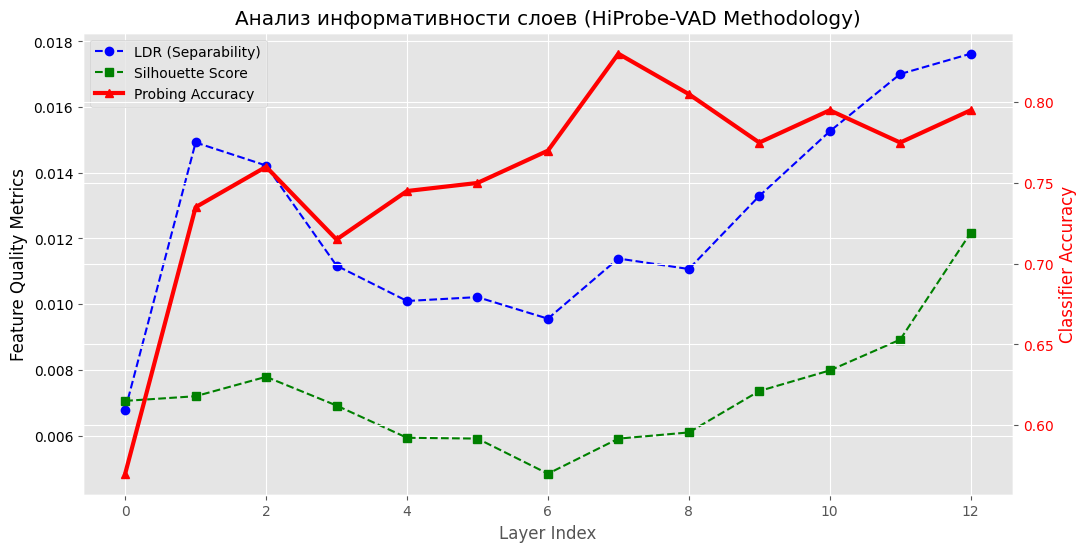

Layer      | Accuracy   | LDR        | Silhouette
--------------------------------------------------
0          | 0.5700     | 0.0068     | 0.0071
1          | 0.7350     | 0.0149     | 0.0072
2          | 0.7600     | 0.0142     | 0.0078
3          | 0.7150     | 0.0112     | 0.0069
4          | 0.7450     | 0.0101     | 0.0059
5          | 0.7500     | 0.0102     | 0.0059
6          | 0.7700     | 0.0096     | 0.0048
7          | 0.8300     | 0.0114     | 0.0059
8          | 0.8050     | 0.0111     | 0.0061
9          | 0.7750     | 0.0133     | 0.0074
10         | 0.7950     | 0.0153     | 0.0080
11         | 0.7750     | 0.0170     | 0.0089
12         | 0.7950     | 0.0176     | 0.0122
--------------------------------------------------
Вывод: Наиболее информативный слой для задачи: 7


In [11]:
layers_range = range(len(hidden_states_per_layer))

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(layers_range, ldr_list, marker='o', label='LDR (Separability)', color='blue', linestyle='--')
ax1.plot(layers_range, sil_list, marker='s', label='Silhouette Score', color='green', linestyle='--')
ax1.set_xlabel('Layer Index')
ax1.set_ylabel('Feature Quality Metrics', color='black')
ax1.tick_params(axis='y', labelcolor='black')

ax2 = ax1.twinx()
ax2.plot(layers_range, probing_acc, marker='^', label='Probing Accuracy', color='red', linewidth=3)
ax2.set_ylabel('Classifier Accuracy', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Анализ информативности слоев (HiProbe-VAD Methodology)')
plt.grid(True)
plt.show()

print(f"{'Layer':<10} | {'Accuracy':<10} | {'LDR':<10} | {'Silhouette':<10}")
print("-" * 50)
for i in range(len(layers_range)):
    print(f"{i:<10} | {probing_acc[i]:.4f}     | {ldr_list[i]:.4f}     | {sil_list[i]:.4f}")

best_layer = np.argmax(probing_acc)
print("-" * 50)
print(f"Вывод: Наиболее информативный слой для задачи: {best_layer}")

В примере с GPT-2 мы также можем наблюдать как последние слои хуже работают, чем предыдущие (например 7 и 8). Гипотеза подтверждается. Это происходит из-за того, что промежуточные слои содержат богатые, многоуровневые представления, а последний слой имеет одну узкую задачу - сопоставить эти представления с конкретным токеном в словаре. В процессе обучения он учится акцентировать признаки, важные именно для предсказания следующего слова, и игнорировать другие, потенциально полезные для иных задач. Это "зашумляет" общее представление, делая его менее универсальным.